# Model Output Data Visualization

### Read Me

This notebook vizualizes model outputs for supervised neural methods from the rPPG Toolbox. To use this notebook follow the following steps:

* STEP 1: Specify the `TEST.OUTPUT_SAVE_DIR` field in the `.yaml` config file of a neural method experiment.
* STEP 2: Run the neural method experiment. A `.pickle` file containing the test-data predictions and labels will be created in `TEST.OUTPUT_SAVE_DIR`.
* STEP 3: Add the path to the `pickle` file in the `TODO: Variable to Set` section as `data_out_path`.
* STEP 4: Add values for `trial_idx` (a value between 0 and the `Num Trials` print in the previous cell), `chunk_size` (number of samples to plot out), `chunk_num` (the chunk of size `chunk_size` in the signal). We suggest using the defaults at first.
* STEP 5: Run all cells. The predicted output, plotted against the ground truth ppg waveform, will be plotted in the final cell

### Imports

In [1]:
# !pip install natsort
!pip install scipy
# !pip install natsort
# !pip install ipywidgets

import cv2
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import re

import torch

import numpy as np
# import ipywidgets as widgets
from IPython.display import display, clear_output
from natsort import natsorted
import os
import scipy
from scipy.sparse import spdiags
from scipy.signal import butter
import math
from scipy import linalg
from scipy import signal
from scipy import sparse

### Helper Functions

In [2]:
# HELPER FUNCTIONS

def _reform_data_from_dict(data, flatten=True):
    """Helper func for calculate metrics: reformat predictions and labels from dicts. """
    sort_data = sorted(data.items(), key=lambda x: x[0])
    sort_data = [i[1] for i in sort_data]
    sort_data = torch.cat(sort_data, dim=0)

    if flatten:
        sort_data = np.reshape(sort_data.cpu(), (-1))
    else:
        sort_data = np.array(sort_data.cpu())

    return sort_data

def _process_signal(signal, fs=30, diff_flag=True):
    # Detrend and filter
    use_bandpass = True
    if diff_flag:  # if the predictions and labels are 1st derivative of PPG signal.
        gt_bvp = _detrend(np.cumsum(signal), 100)
    else:
        gt_bvp = _detrend(signal, 100)
    if use_bandpass:
        # bandpass filter between [0.75, 2.5] Hz
        # equals [45, 150] beats per min
        [b, a] = butter(1, [0.75 / fs * 2, 2.5 / fs * 2], btype='bandpass')
        signal = scipy.signal.filtfilt(b, a, np.double(signal))
    return signal

def _detrend(input_signal, lambda_value):
    """Detrend PPG signal."""
    signal_length = input_signal.shape[0]
    # observation matrix
    H = np.identity(signal_length)
    ones = np.ones(signal_length)
    minus_twos = -2 * np.ones(signal_length)
    diags_data = np.array([ones, minus_twos, ones])
    diags_index = np.array([0, 1, 2])
    D = spdiags(diags_data, diags_index,
                (signal_length - 2), signal_length).toarray()
    detrended_signal = np.dot(
        (H - np.linalg.inv(H + (lambda_value ** 2) * np.dot(D.T, D))), input_signal)
    return detrended_signal


### TODO: Variables To Set

In [15]:
# Reference model: label signal is always taken from this pickle
ref_data_path = "/ssd3/jiho_data/MS-rPPG/runs/exp/Diff_160/saved_test_outputs/mrnirp_loss_time_0_6_outputs.pickle"

# Additional models to overlay (display_name -> pickle_path)
# Each model's prediction is processed with its own label_type (diff_flag), but label is always from ref
pred_data_paths = {
    "RhythmMamba": "/ssd3/jiho_data/MS-rPPG/runs/exp/Standardized_160/saved_test_outputs/mrnirp_rhythmmamba_Epoch29_Seed0_MR-NIRP_outputs.pickle",
    "PhysMamba": "/ssd3/jiho_data/MS-rPPG/runs/exp/Diff_128/saved_test_outputs/mrnirp_physmamba_outputs.pickle",
}

include_ref_prediction = True  # also plot the reference model's own prediction

trial_idx = 2
chunk_size = 160  # -1 to plot entire signal
chunk_num = 9

# MR-NIRP best: trial_idx = 2, chunk_size = 160, chunk_num = 9
# PhysDrive best: trial_idx = 4, chunk_size = 160, chunk_num = 6, 5

### Read Data, and Extract Trials List

In [16]:
# Load reference data (label source + trial list)
with open(ref_data_path, 'rb') as f:
    ref_data = pickle.load(f)

trial_list = list(ref_data['predictions'].keys())
print('Num Trials:', len(trial_list))
for i, t in enumerate(trial_list):
    print(f'  [{i}] {t}')

Num Trials: 12
  [0] subject15_driving_large_motion_975
  [1] subject15_driving_small_motion_975
  [2] subject15_driving_still_motion_975
  [3] subject17_driving_large_motion_975
  [4] subject17_driving_small_motion_975
  [5] subject17_driving_still_motion_975
  [6] subject18_driving_large_motion_975
  [7] subject18_driving_small_motion_975
  [8] subject18_driving_still_motion_975
  [9] subject19_driving_large_motion_975
  [10] subject19_driving_small_motion_975
  [11] subject19_driving_still_motion_975


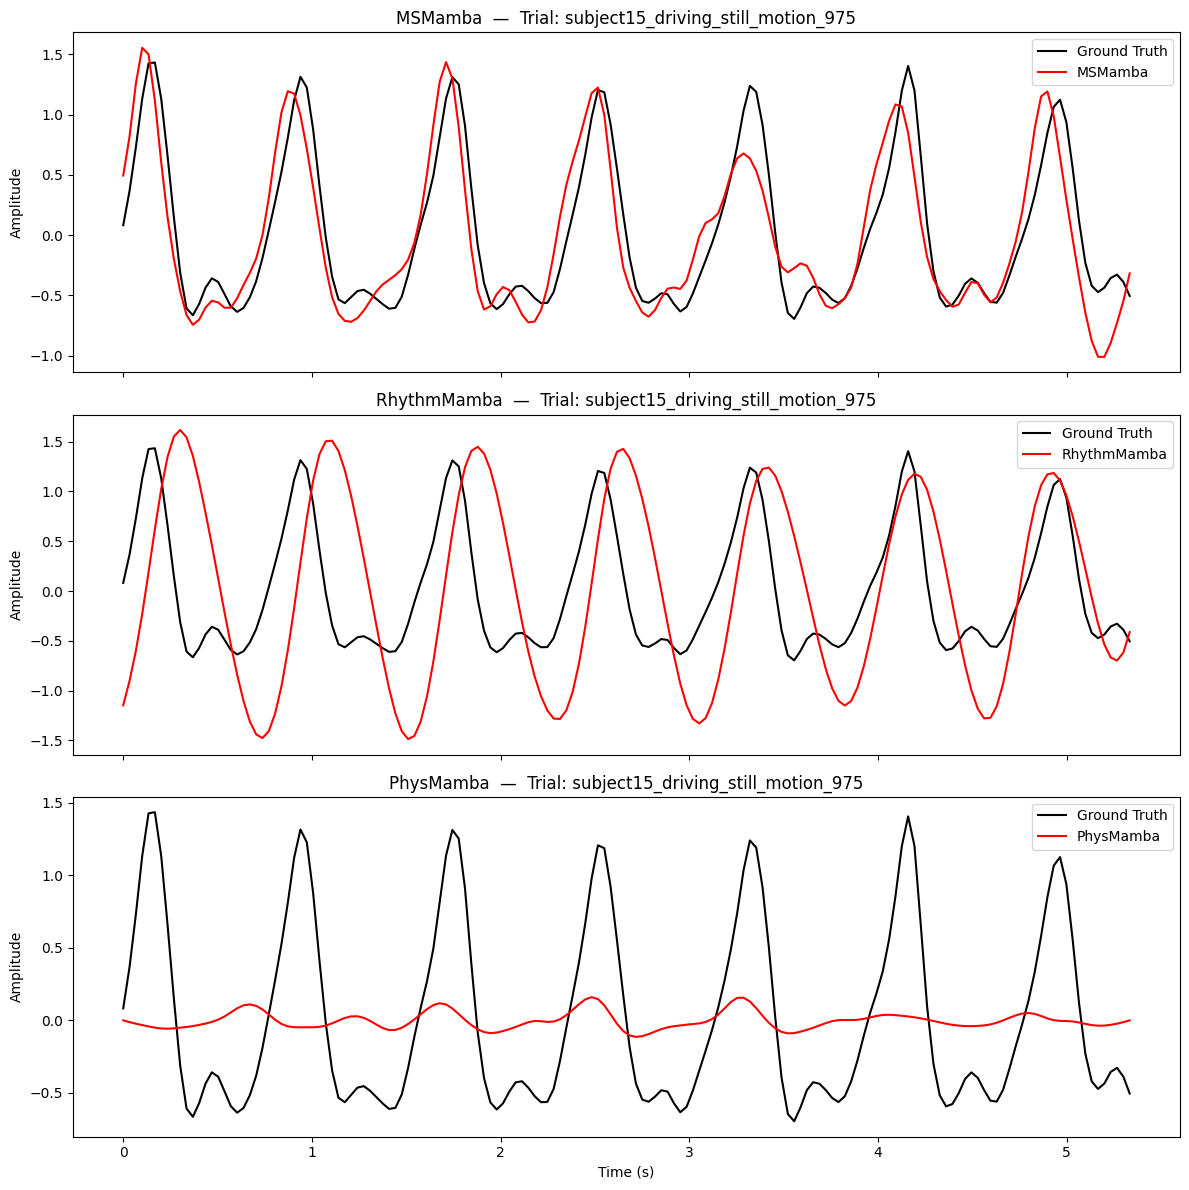

In [17]:
# Extract label from reference model
label_raw = np.array(_reform_data_from_dict(ref_data['labels'][trial_list[trial_idx]]))
fs = ref_data['fs']
ref_label_type = ref_data['label_type']
ref_diff_flag = (ref_label_type == 'DiffNormalized')

if chunk_size == -1:
    chunk_size = len(label_raw)
    chunk_num = 0

label = _process_signal(label_raw, fs, diff_flag=ref_diff_flag)
start = chunk_num * chunk_size
stop  = (chunk_num + 1) * chunk_size
samples = stop - start
x_time = np.linspace(0, samples / fs, num=samples)

# Collect predictions
all_predictions = {}

if include_ref_prediction:
    pred_raw = np.array(_reform_data_from_dict(ref_data['predictions'][trial_list[trial_idx]]))
    all_predictions["MSMamba"] = _process_signal(pred_raw, fs, diff_flag=ref_diff_flag)

for model_name, path in pred_data_paths.items():
    with open(path, 'rb') as f:
        model_data = pickle.load(f)
    pred_raw = np.array(_reform_data_from_dict(model_data['predictions'][trial_list[trial_idx]]))
    model_fs = model_data['fs']
    model_diff_flag = (model_data['label_type'] == 'DiffNormalized')
    all_predictions[model_name] = _process_signal(pred_raw, model_fs, diff_flag=model_diff_flag)

# One subplot per model: GT (black) vs prediction (red)
n_models = len(all_predictions)
fig, axes = plt.subplots(n_models, 1, figsize=(12, 4 * n_models), sharex=True)
if n_models == 1:
    axes = [axes]

gt_chunk = label[start:stop]
for ax, (model_name, pred) in zip(axes, all_predictions.items()):
    ax.plot(x_time, gt_chunk, color='black', linewidth=1.5, label='Ground Truth')
    ax.plot(x_time, pred[start:stop], color='red', linewidth=1.5, label=model_name)
    ax.set_title(f'{model_name}  —  Trial: {trial_list[trial_idx]}')
    ax.legend(loc='upper right')
    ax.set_ylabel('Amplitude')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()